# 🛒 Dark Store Demand Forecast
## Slot-Utilisation Dashboard — PIN 560068, Bellandur, Bengaluru

**Objective:** Simulate 6 months of hourly order data, identify underutilised picker slots by hour-of-day and day-of-week, then forecast next 7 days using ARIMA and Prophet.

| | |
|---|---|
| **Store** | Bellandur Dark Store |
| **PIN Code** | 560068 |
| **History** | 6 months (Oct 2024 – Mar 2025) |
| **Forecast horizon** | 7 days |
| **Models** | SARIMA(1,1,1)(1,0,1)[7] + Facebook Prophet |


## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

# ── Constants ────────────────────────────────────────────────
STORE_PIN     = "560068"
STORE_NAME    = "Bellandur Dark Store"
SIM_DAYS      = 180       # 6 months of history
HOLDOUT       = 14        # days reserved for test evaluation
FORECAST_DAYS = 7
START_DATE    = datetime(2024, 10, 1)

print(f"✅  Config loaded | Store: {STORE_NAME} | PIN: {STORE_PIN}")


Importing plotly failed. Interactive plots will not work.


✅  Config loaded | Store: Bellandur Dark Store | PIN: 560068


## 2. Simulate Hourly Order Data

Realistic Bengaluru quick-commerce demand patterns:
- **Morning spike** 07–09 (breakfast, milk)
- **Evening surge** 17–21 (dinner groceries, snacks)
- **Weekend uplift** +25%
- **Pay-cycle bump** first & last 5 days of month (+12%)
- **Mild upward trend** (+0.3% per week)


In [2]:
hours = pd.date_range(start=START_DATE, periods=SIM_DAYS * 24, freq="h")

# Hour-of-day demand weights (index = hour 0–23)
hourly_weights = np.array([
    0.1, 0.05, 0.03, 0.02, 0.02, 0.05,   # 00–05  overnight low
    0.3,  0.9,  1.0,  0.7,  0.5,  0.4,   # 06–11  morning spike
    0.5,  0.4,  0.45, 0.5,  0.6,  0.9,   # 12–17  afternoon
    1.0,  1.0,  0.95, 0.8,  0.6,  0.3,   # 18–23  evening surge
])

def simulate_orders(ts_index):
    orders = []
    for ts in ts_index:
        base        = 18
        hour_factor = hourly_weights[ts.hour]
        dow_factor  = 1.25 if ts.dayofweek >= 5 else 1.0
        dom, mdays  = ts.day, (ts + pd.offsets.MonthEnd(0)).day
        pay_factor  = 1.12 if (dom <= 5 or dom >= mdays - 4) else 1.0
        week_num    = (ts - pd.Timestamp(START_DATE)).days // 7
        trend       = 1 + 0.003 * week_num
        mu          = base * hour_factor * dow_factor * pay_factor * trend
        orders.append(np.random.poisson(max(mu, 0.1)))
    return orders

df_hourly = pd.DataFrame({"ds": hours, "orders": simulate_orders(hours)})

# Daily rollup — used for model training
df_daily = (
    df_hourly.resample("D", on="ds").sum()
    .rename(columns={"orders": "y"}).reset_index()
)

print(f"Hourly rows : {len(df_hourly):,}")
print(f"Daily rows  : {len(df_daily)}")
print(f"Orders/day  — min: {df_daily.y.min()}, max: {df_daily.y.max()}, mean: {df_daily.y.mean():.1f}")
df_daily.tail()


Hourly rows : 4,320
Daily rows  : 180
Orders/day  — min: 178, max: 352, mean: 250.0


,ds,y
175,2025-03-25,241
176,2025-03-26,232
177,2025-03-27,268
178,2025-03-28,266
179,2025-03-29,324


## 3. Slot Utilisation Heatmap (Hour × Day-of-Week)

Simulates picker slot capacity (8 slots, ~6 orders/slot/hr peak) and derives utilisation.


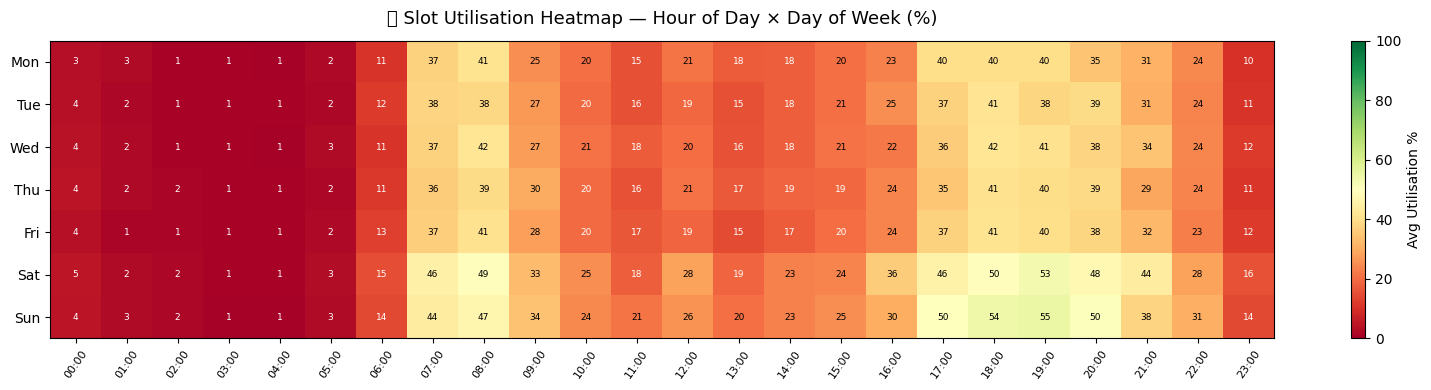

✅  Cells below 40% = underutilised (red), above 85% = overloaded (dark green)


In [3]:
SLOT_CAPACITY_PER_HOUR = 6 * 8   # 8 slots × 6 orders/hr theoretical max

df_slot = df_hourly.copy()
df_slot["dow"]         = df_slot.ds.dt.dayofweek           # 0=Mon
df_slot["hour"]        = df_slot.ds.dt.hour
df_slot["capacity"]    = SLOT_CAPACITY_PER_HOUR
df_slot["utilisation"] = (df_slot["orders"] / df_slot["capacity"]).clip(upper=1.0) * 100

pivot = (
    df_slot.groupby(["dow", "hour"])["utilisation"]
    .mean().unstack("hour").reindex(range(7))
)

days_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_yticks(range(7)); ax.set_yticklabels(days_labels)
ax.set_xticks(range(24)); ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=55, fontsize=8)
ax.set_title("📊 Slot Utilisation Heatmap — Hour of Day × Day of Week (%)", fontsize=13, pad=12)
plt.colorbar(im, ax=ax, label="Avg Utilisation %")

for i in range(7):
    for j in range(24):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                fontsize=6.5, color="black" if 20 < v < 80 else "white")

plt.tight_layout()
plt.savefig("slot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Cells below 40% = underutilised (red), above 85% = overloaded (dark green)")


## 4. Underutilised Slot Report

Flags hour × day-of-week combinations where average utilisation < 40%.


In [4]:
slot_summary = (
    df_slot.groupby(["dow", "hour"])
    .agg(avg_orders=("orders","mean"), avg_util=("utilisation","mean"))
    .reset_index()
)
slot_summary["day_label"] = slot_summary["dow"].map(
    {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
)
slot_summary["band"] = pd.cut(
    slot_summary["avg_util"],
    bins=[0, 40, 85, 100],
    labels=["🔴 Underutilised", "🟢 Optimal", "🟡 Overloaded"]
)

underutil = slot_summary[slot_summary["avg_util"] < 40].sort_values("avg_util")
print(f"Underutilised slots (util < 40%): {len(underutil)} out of {len(slot_summary)} hour-day combos\n")
underutil[["day_label","hour","avg_orders","avg_util","band"]].head(15)


Underutilised slots (util < 40%): 145 out of 168 hour-day combos



,day_label,hour,avg_orders,avg_util,band
52,Wed,4,0.269231,0.560897,🔴 Underutilised
4,Mon,4,0.280000,0.583333,🔴 Underutilised
147,Sun,3,0.320000,0.666667,🔴 Underutilised
148,Sun,4,0.320000,0.666667,🔴 Underutilised
75,Thu,3,0.384615,0.801282,🔴 Underutilised
2,Mon,2,0.400000,0.833333,🔴 Underutilised
50,Wed,2,0.423077,0.881410,🔴 Underutilised
28,Tue,4,0.423077,0.881410,🔴 Underutilised
124,Sat,4,0.423077,0.881410,🔴 Underutilised
27,Tue,3,0.423077,0.881410,🔴 Underutilised


## 4B. Wasted Picker Capacity — Quantified

The heatmap shows *where* utilisation is low. This section answers the real operational question:

> **Which hour-day slots are chronically wasting picker capacity, how many hours are lost per week, and what does that cost?**

Assumptions:
- **8 picker slots**, each working a 1-hour shift-block
- **Waste threshold:** avg utilisation < 40% → picker idle more than they're active
- **Picker cost:** ₹120 / hr (typical Bengaluru dark-store contract rate)
- A *wasted picker-hour* = one slot running for one hour below the 40% threshold


In [5]:
# ── Constants ────────────────────────────────────────────────────────────────
PICKER_COST_PER_HOUR = 120       # ₹ per picker per hour
NUM_SLOTS            = 8
UNDERUTIL_THRESHOLD  = 40        # % below which a slot is "wasted"

# ── Step 1: Average utilisation per (dow, hour) ───────────────────────────────
slot_summary = (
    df_slot.groupby(["dow", "hour"])
    .agg(
        avg_orders   = ("orders",      "mean"),
        avg_util_pct = ("utilisation", "mean"),
    )
    .reset_index()
)

slot_summary["day_label"] = slot_summary["dow"].map(
    {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
)

# ── Step 2: Compute waste per slot-hour ───────────────────────────────────────
# idle_picker_slots = avg number of the 8 physical slots sitting idle
slot_summary["is_wasted"]         = slot_summary["avg_util_pct"] < UNDERUTIL_THRESHOLD
slot_summary["idle_picker_slots"] = (
    NUM_SLOTS * (1 - slot_summary["avg_util_pct"] / 100)
).round(2)

# wasted_hrs_per_week: picker-hours lost in this slot per typical week
slot_summary["wasted_hrs_per_week"] = slot_summary.apply(
    lambda r: r["idle_picker_slots"] if r["is_wasted"] else 0, axis=1
)
slot_summary["weekly_cost_inr"] = (
    slot_summary["wasted_hrs_per_week"] * PICKER_COST_PER_HOUR
).round(0)

# ── Step 3: Top-line numbers ──────────────────────────────────────────────────
total_wasted_combos = slot_summary["is_wasted"].sum()
total_wasted_hrs_pw = slot_summary["wasted_hrs_per_week"].sum()
total_weekly_cost   = slot_summary["weekly_cost_inr"].sum()
total_monthly_cost  = total_weekly_cost * 4.33

print("=" * 55)
print("  WASTED PICKER CAPACITY SUMMARY")
print("=" * 55)
print(f"  Underutilised hour-day combos : {total_wasted_combos} / {len(slot_summary)}")
print(f"  Wasted picker-hours / week    : {total_wasted_hrs_pw:.1f} hrs")
print(f"  Estimated weekly cost         : Rs.{total_weekly_cost:,.0f}")
print(f"  Estimated monthly cost        : Rs.{total_monthly_cost:,.0f}")
print("=" * 55)


  WASTED PICKER CAPACITY SUMMARY
  Underutilised hour-day combos : 145 / 168
  Wasted picker-hours / week    : 951.9 hrs
  Estimated weekly cost         : Rs.114,230
  Estimated monthly cost        : Rs.494,616


### 4C. Ranked Bar Chart — Wasted Hours by Hour-of-Day

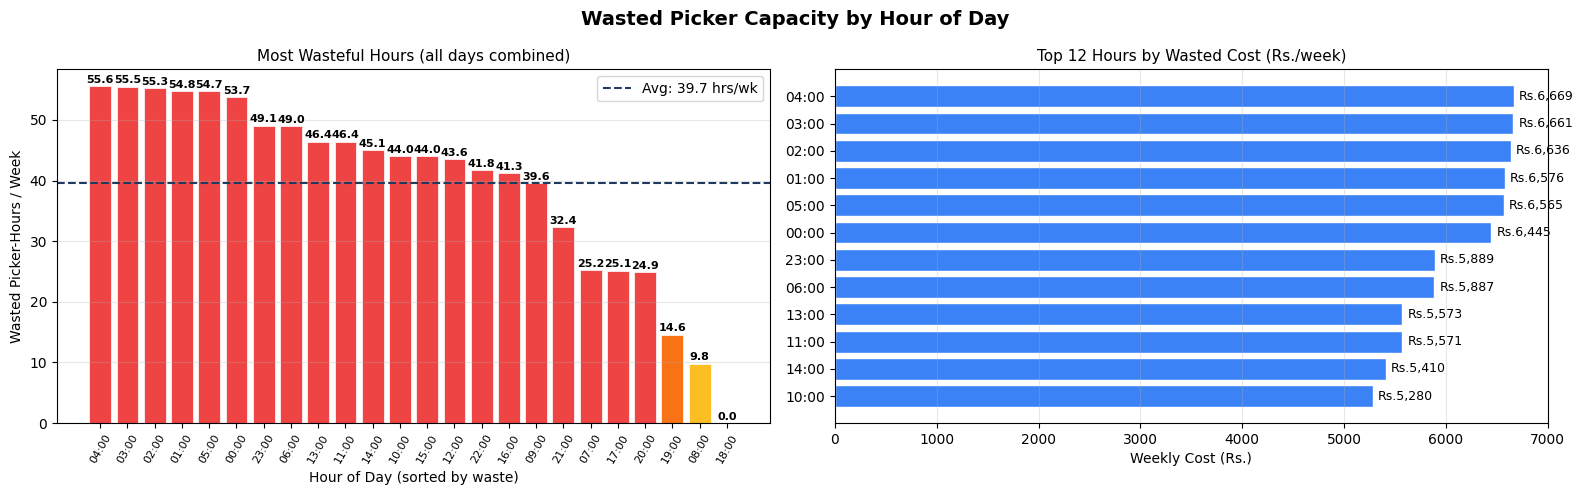

In [6]:
# Aggregate across all 7 days → wasted hrs per hour-of-day
hourly_waste = (
    slot_summary.groupby("hour")
    .agg(
        wasted_hrs  = ("wasted_hrs_per_week", "sum"),
        weekly_cost = ("weekly_cost_inr",     "sum"),
    )
    .reset_index()
    .sort_values("wasted_hrs", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Wasted Picker Capacity by Hour of Day", fontsize=14, fontweight="bold")

# Left: ranked bar chart
colors = [
    "#ef4444" if w > 20 else "#f97316" if w > 10 else "#fbbf24"
    for w in hourly_waste["wasted_hrs"]
]
bars = axes[0].bar(
    hourly_waste["hour"].astype(str).str.zfill(2) + ":00",
    hourly_waste["wasted_hrs"],
    color=colors, edgecolor="white", linewidth=0.5
)
avg_line = hourly_waste["wasted_hrs"].mean()
axes[0].axhline(y=avg_line, color="#1e3a5f", linestyle="--",
                linewidth=1.5, label=f"Avg: {avg_line:.1f} hrs/wk")
for bar, val in zip(bars, hourly_waste["wasted_hrs"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
        f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold"
    )
axes[0].set_xlabel("Hour of Day (sorted by waste)")
axes[0].set_ylabel("Wasted Picker-Hours / Week")
axes[0].set_title("Most Wasteful Hours (all days combined)", fontsize=11)
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=60, fontsize=8)

# Right: cost horizontal bar — top 12 worst hours
cost_sorted = hourly_waste.sort_values("weekly_cost", ascending=True).tail(12)
axes[1].barh(
    cost_sorted["hour"].astype(str).str.zfill(2) + ":00",
    cost_sorted["weekly_cost"],
    color="#3b82f6", edgecolor="white"
)
for i, (_, row) in enumerate(cost_sorted.iterrows()):
    axes[1].text(
        row["weekly_cost"] + 50, i,
        f"Rs.{row['weekly_cost']:,.0f}", va="center", fontsize=9
    )
axes[1].set_xlabel("Weekly Cost (Rs.)")
axes[1].set_title("Top 12 Hours by Wasted Cost (Rs./week)", fontsize=11)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


### 4D. Waste Heatmap — Wasted Picker-Hours per Week (Hour × Day)

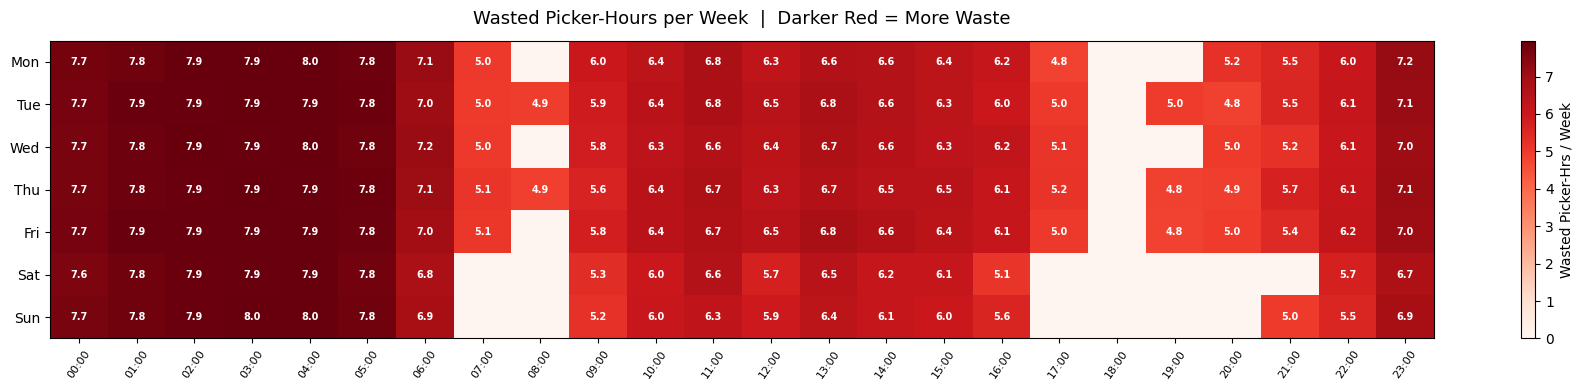

Each cell = wasted picker-hours in that slot per week.
White cells = slot is optimally utilised (no waste).


In [7]:
waste_pivot = (
    slot_summary
    .pivot(index="dow", columns="hour", values="wasted_hrs_per_week")
    .reindex(range(7))
    .fillna(0)
)
days_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(waste_pivot.values, aspect="auto", cmap="Reds", interpolation="nearest")
ax.set_yticks(range(7)); ax.set_yticklabels(days_labels, fontsize=10)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=55, fontsize=8)
ax.set_title("Wasted Picker-Hours per Week  |  Darker Red = More Waste", fontsize=13, pad=12)
plt.colorbar(im, ax=ax, label="Wasted Picker-Hrs / Week")

for i in range(7):
    for j in range(24):
        v = waste_pivot.values[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                    fontsize=7,
                    color="white" if v > 4 else "black",
                    fontweight="bold")

plt.tight_layout()
plt.show()
print("Each cell = wasted picker-hours in that slot per week.")
print("White cells = slot is optimally utilised (no waste).")


### 4E. Day-of-Week Waste Summary Table

In [8]:
dow_waste = (
    slot_summary
    .groupby(["dow", "day_label"])
    .agg(
        total_wasted_hrs = ("wasted_hrs_per_week", "sum"),
        total_cost_inr   = ("weekly_cost_inr",     "sum"),
    )
    .reset_index()
    .sort_values("total_wasted_hrs", ascending=False)
)

# Find the single worst hour per day
worst_hours = (
    slot_summary[slot_summary["is_wasted"]]
    .sort_values("wasted_hrs_per_week", ascending=False)
    .groupby("dow")
    .first()
    .reset_index()[["dow","hour"]]
)
dow_waste = dow_waste.merge(worst_hours, on="dow", how="left")
dow_waste["Peak Waste Hour"]  = dow_waste["hour"].apply(
    lambda h: f"{int(h):02d}:00" if not np.isnan(h) else "—"
)
dow_waste["Monthly Cost (Rs.)"] = (dow_waste["total_cost_inr"] * 4.33).round(0).astype(int)
dow_waste["total_wasted_hrs"]   = dow_waste["total_wasted_hrs"].round(1)
dow_waste["total_cost_inr"]     = dow_waste["total_cost_inr"].astype(int)

display_df = dow_waste.rename(columns={
    "day_label":       "Day",
    "total_wasted_hrs":"Wasted Hrs/Week",
    "total_cost_inr":  "Weekly Cost (Rs.)",
})[["Day","Wasted Hrs/Week","Weekly Cost (Rs.)","Monthly Cost (Rs.)","Peak Waste Hour"]]

display_df.style.background_gradient(subset=["Wasted Hrs/Week"], cmap="Reds")


,Day,Wasted Hrs/Week,Weekly Cost (Rs.),Monthly Cost (Rs.),Peak Waste Hour
0,Tue,149.000000,17877,77407,04:00
1,Thu,148.700000,17844,77265,03:00
2,Fri,144.000000,17274,74796,04:00
3,Mon,139.200000,16705,72333,04:00
4,Wed,138.700000,16640,72051,04:00
5,Sun,118.800000,14259,61741,03:00
6,Sat,113.600000,13631,59022,04:00


### 4F. Reallocation Recommendations

Specific actions for the ops manager — ranked by weekly saving potential.


In [9]:
# Top 10 wasted slot-hours and what to do about them
top_waste = (
    slot_summary[slot_summary["is_wasted"]]
    .sort_values("wasted_hrs_per_week", ascending=False)
    .head(10)
    .copy()
)

top_waste["slots_to_remove"] = (
    (top_waste["idle_picker_slots"] * 0.6)
    .apply(np.floor)
    .astype(int)
    .clip(lower=1)
)
top_waste["saving_per_week"] = top_waste["slots_to_remove"] * PICKER_COST_PER_HOUR
top_waste["action"] = top_waste.apply(
    lambda r: (
        f"Reduce active slots {NUM_SLOTS} -> {NUM_SLOTS - r['slots_to_remove']}"
        f" on {r['day_label']} {int(r['hour']):02d}:00"
    ), axis=1
)

print("TOP 10 SLOT-HOUR REALLOCATION RECOMMENDATIONS")
print("=" * 68)
for rank, (_, row) in enumerate(top_waste.iterrows(), 1):
    print(f"  #{rank:02d}  {row['action']}")
    print(f"       Utilisation: {row['avg_util_pct']:.1f}%  |"
          f"  Idle slots: {row['idle_picker_slots']:.1f}  |"
          f"  Weekly saving: Rs.{row['saving_per_week']:,}")
    print()

total_saving_wk = top_waste["saving_per_week"].sum()
print("-" * 68)
print(f"  Weekly saving  (top 10 actions) : Rs.{total_saving_wk:,}")
print(f"  Monthly saving (top 10 actions) : Rs.{total_saving_wk * 4.33:,.0f}")


TOP 10 SLOT-HOUR REALLOCATION RECOMMENDATIONS
  #01  Reduce active slots 8 -> 4 on Wed 04:00
       Utilisation: 0.6%  |  Idle slots: 8.0  |  Weekly saving: Rs.480

  #02  Reduce active slots 8 -> 4 on Sun 03:00
       Utilisation: 0.7%  |  Idle slots: 8.0  |  Weekly saving: Rs.480

  #03  Reduce active slots 8 -> 4 on Sun 04:00
       Utilisation: 0.7%  |  Idle slots: 8.0  |  Weekly saving: Rs.480

  #04  Reduce active slots 8 -> 4 on Mon 04:00
       Utilisation: 0.6%  |  Idle slots: 8.0  |  Weekly saving: Rs.480

  #05  Reduce active slots 8 -> 4 on Thu 03:00
       Utilisation: 0.8%  |  Idle slots: 7.9  |  Weekly saving: Rs.480

  #06  Reduce active slots 8 -> 4 on Mon 03:00
       Utilisation: 0.9%  |  Idle slots: 7.9  |  Weekly saving: Rs.480

  #07  Reduce active slots 8 -> 4 on Mon 02:00
       Utilisation: 0.8%  |  Idle slots: 7.9  |  Weekly saving: Rs.480

  #08  Reduce active slots 8 -> 4 on Fri 04:00
       Utilisation: 0.9%  |  Idle slots: 7.9  |  Weekly saving: Rs.480

  

## 5. Train / Test Split

Train: 2024-10-01 → 2025-03-15  (166 days)
Test : 2025-03-16  → 2025-03-29  (14 days)


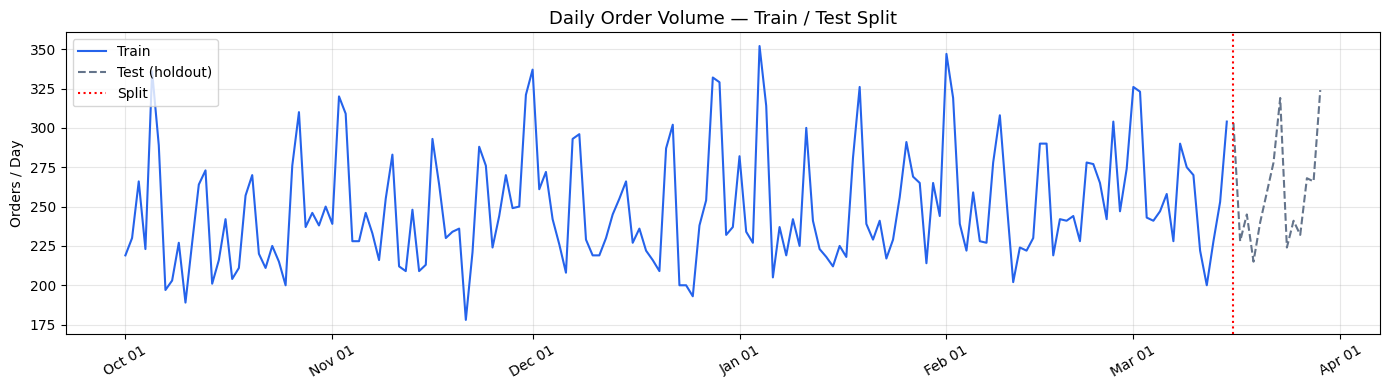

In [10]:
train = df_daily.iloc[:-HOLDOUT].copy()
test  = df_daily.iloc[-HOLDOUT:].copy()

print(f"Train: {train.ds.min().date()} → {train.ds.max().date()}  ({len(train)} days)")
print(f"Test : {test.ds.min().date()}  → {test.ds.max().date()}  ({len(test)} days)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.ds, train.y, color="#2563eb", lw=1.5, label="Train")
ax.plot(test.ds,  test.y,  color="#64748b", lw=1.5, linestyle="--", label="Test (holdout)")
ax.axvline(test.ds.iloc[0], color="red", linestyle=":", lw=1.5, label="Split")
ax.set_title("Daily Order Volume — Train / Test Split", fontsize=13)
ax.set_ylabel("Orders / Day"); ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 6. Stationarity Check (ADF Test)

In [11]:
adf_stat, p_val, _, _, crit_vals, _ = adfuller(train["y"].values, autolag="AIC")

print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value       : {p_val:.4f}")
print(f"Critical values: {crit_vals}")
print()
if p_val < 0.05:
    print("✅  Series is stationary — no differencing needed before ARIMA")
else:
    print("⚠️  Non-stationary — SARIMA will apply d=1 differencing")


ADF Statistic : -3.1368
p-value       : 0.0239
Critical values: {'1%': np.float64(-3.4744158894942156), '5%': np.float64(-2.880878382771059), '10%': np.float64(-2.577081275821236)}

✅  Series is stationary — no differencing needed before ARIMA


## 7. SARIMA Model

`SARIMA(1,1,1)(1,0,1)[7]` — AR(1) + MA(1) with weekly seasonal AR and MA.


In [12]:
sarima_model = SARIMAX(
    train["y"],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())


                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  166
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                -711.329
Date:                           Sun, 12 Apr 2026   AIC                           1432.658
Time:                                   16:04:48   BIC                           1447.907
Sample:                                        0   HQIC                          1438.851
                                           - 166                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1180      0.112      1.058      0.290      -0.101       0.337
ma.L1         -0.7494      0.085     -8.767

In [13]:
sarima_test_pred = np.maximum(sarima_fit.forecast(steps=HOLDOUT), 0)
sarima_forecast  = np.maximum(sarima_fit.forecast(steps=HOLDOUT + FORECAST_DAYS)[-FORECAST_DAYS:], 0)

sarima_mae  = mean_absolute_error(test["y"], sarima_test_pred)
sarima_rmse = np.sqrt(mean_squared_error(test["y"], sarima_test_pred))
sarima_mape = np.mean(np.abs((test["y"].values - sarima_test_pred) / np.maximum(test["y"].values, 1))) * 100

print(f"SARIMA  →  MAE: {sarima_mae:.2f}  |  RMSE: {sarima_rmse:.2f}  |  MAPE: {sarima_mape:.2f}%")


SARIMA  →  MAE: 17.11  |  RMSE: 19.82  |  MAPE: 6.53%


## 8. Prophet Model

Adds Bengaluru / Indian national holidays and a monthly seasonality component.


In [14]:
holidays_df = pd.DataFrame({
    "holiday": ["Diwali","Kannada Rajyotsava","Christmas",
                "New Year","Republic Day","Holi","Ugadi"],
    "ds": pd.to_datetime([
        "2024-11-01","2024-11-01","2024-12-25",
        "2025-01-01","2025-01-26","2025-03-14","2025-03-30"
    ]),
    "lower_window": [-1,-1, 0,-1, 0, 0, 0],
    "upper_window": [ 1, 0, 1, 1, 0, 1, 1],
})

m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays_df,
    changepoint_prior_scale=0.15,
    seasonality_prior_scale=10,
    interval_width=0.90,
)
m.add_seasonality(name="monthly", period=30.5, fourier_order=4)
m.fit(train[["ds","y"]])
print("✅  Prophet model trained")


16:04:48 - cmdstanpy - INFO - Chain [1] start processing
16:04:48 - cmdstanpy - INFO - Chain [1] done processing


✅  Prophet model trained


In [15]:
future      = m.make_future_dataframe(periods=HOLDOUT + FORECAST_DAYS)
prophet_all = m.predict(future)

prophet_test_pred    = np.maximum(prophet_all.iloc[-(HOLDOUT + FORECAST_DAYS):-FORECAST_DAYS]["yhat"].values, 0)
prophet_forecast_df  = prophet_all.iloc[-FORECAST_DAYS:][["ds","yhat","yhat_lower","yhat_upper"]].copy()
prophet_forecast_df["yhat"]       = np.maximum(prophet_forecast_df["yhat"], 0)
prophet_forecast_df["yhat_lower"] = np.maximum(prophet_forecast_df["yhat_lower"], 0)

prophet_mae  = mean_absolute_error(test["y"], prophet_test_pred)
prophet_rmse = np.sqrt(mean_squared_error(test["y"], prophet_test_pred))
prophet_mape = np.mean(np.abs((test["y"].values - prophet_test_pred) / np.maximum(test["y"].values, 1))) * 100

print(f"Prophet →  MAE: {prophet_mae:.2f}  |  RMSE: {prophet_rmse:.2f}  |  MAPE: {prophet_mape:.2f}%")


Prophet →  MAE: 14.70  |  RMSE: 17.34  |  MAPE: 5.65%


## 9. Model Comparison

In [16]:
results = pd.DataFrame({
    "Model":  ["SARIMA(1,1,1)(1,0,1)[7]", "Prophet"],
    "MAE":    [round(sarima_mae,2),  round(prophet_mae,2)],
    "RMSE":   [round(sarima_rmse,2), round(prophet_rmse,2)],
    "MAPE %": [round(sarima_mape,2), round(prophet_mape,2)],
})
results["Winner"] = results["RMSE"] == results["RMSE"].min()
results.style.highlight_min(subset=["MAE","RMSE","MAPE %"], color="#bbf7d0")


,Model,MAE,RMSE,MAPE %,Winner
0,"SARIMA(1,1,1)(1,0,1)[7]",17.110000,19.820000,6.530000,False
1,Prophet,14.700000,17.340000,5.650000,True


## 10. Test Set Comparison Plot

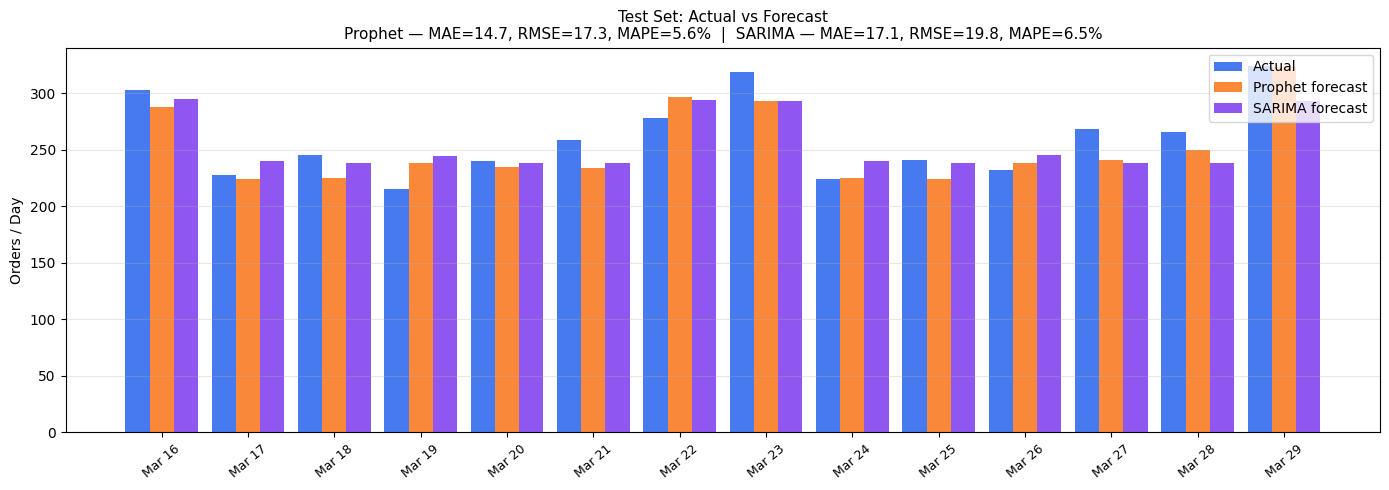

In [17]:
x = np.arange(HOLDOUT)
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, test["y"].values,      width, label="Actual",          color="#2563eb", alpha=0.85)
ax.bar(x,         prophet_test_pred,      width, label="Prophet forecast", color="#f97316", alpha=0.85)
ax.bar(x + width, sarima_test_pred,       width, label="SARIMA forecast",  color="#7c3aed", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b %d") for d in test["ds"]], rotation=40, fontsize=9)
ax.set_title(
    f"Test Set: Actual vs Forecast\n"
    f"Prophet — MAE={prophet_mae:.1f}, RMSE={prophet_rmse:.1f}, MAPE={prophet_mape:.1f}%  |  "
    f"SARIMA — MAE={sarima_mae:.1f}, RMSE={sarima_rmse:.1f}, MAPE={sarima_mape:.1f}%",
    fontsize=11
)
ax.set_ylabel("Orders / Day"); ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 11. 7-Day Demand Forecast

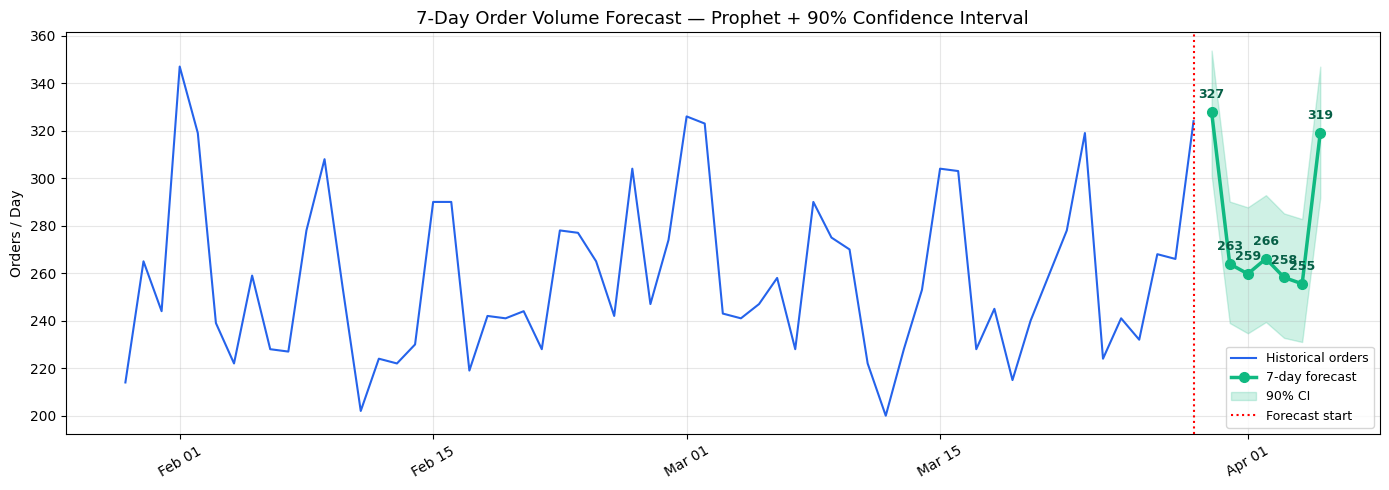

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

# History (last 60 days for context)
hist = df_daily.tail(60)
ax.plot(hist.ds, hist.y, color="#2563eb", lw=1.5, label="Historical orders")

# Forecast + CI
ax.plot(prophet_forecast_df.ds, prophet_forecast_df.yhat,
        color="#10b981", lw=2.5, marker="o", markersize=7, label="7-day forecast")
ax.fill_between(prophet_forecast_df.ds,
                prophet_forecast_df.yhat_lower,
                prophet_forecast_df.yhat_upper,
                alpha=0.2, color="#10b981", label="90% CI")

# Annotate forecast values
for _, row in prophet_forecast_df.iterrows():
    ax.annotate(f"{int(row.yhat)}", xy=(row.ds, row.yhat),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="#065f46", fontweight="bold")

ax.axvline(df_daily.ds.max(), color="red", linestyle=":", lw=1.5, label="Forecast start")
ax.set_title("7-Day Order Volume Forecast — Prophet + 90% Confidence Interval", fontsize=13)
ax.set_ylabel("Orders / Day"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


In [19]:
# Clean forecast table
forecast_table = prophet_forecast_df.copy()
forecast_table["Day"]            = forecast_table["ds"].dt.strftime("%A")
forecast_table["Forecast Orders"]= forecast_table["yhat"].round().astype(int)
forecast_table["Lower 90%"]      = forecast_table["yhat_lower"].round().astype(int)
forecast_table["Upper 90%"]      = forecast_table["yhat_upper"].round().astype(int)
forecast_table = forecast_table.rename(columns={"ds":"Date"})[
    ["Date","Day","Forecast Orders","Lower 90%","Upper 90%"]
]
forecast_table


,Date,Day,Forecast Orders,Lower 90%,Upper 90%
180,2025-03-30,Sunday,328,301,354
181,2025-03-31,Monday,264,239,290
182,2025-04-01,Tuesday,260,235,288
183,2025-04-02,Wednesday,266,239,293
184,2025-04-03,Thursday,258,233,285
185,2025-04-04,Friday,256,231,283
186,2025-04-05,Saturday,319,292,347


## 12. Export Forecast CSV

In [20]:
forecast_table["store_pin"]    = STORE_PIN
forecast_table["model"]        = "Prophet"
forecast_table["generated_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
forecast_table.to_csv("02_7day_forecast.csv", index=False)
print("✅  Saved → 02_7day_forecast.csv")
forecast_table


✅  Saved → 02_7day_forecast.csv


,Date,Day,Forecast Orders,Lower 90%,Upper 90%,store_pin,model,generated_at
180,2025-03-30,Sunday,328,301,354,560068,Prophet,2026-04-12 16:04:49
181,2025-03-31,Monday,264,239,290,560068,Prophet,2026-04-12 16:04:49
182,2025-04-01,Tuesday,260,235,288,560068,Prophet,2026-04-12 16:04:49
183,2025-04-02,Wednesday,266,239,293,560068,Prophet,2026-04-12 16:04:49
184,2025-04-03,Thursday,258,233,285,560068,Prophet,2026-04-12 16:04:49
185,2025-04-04,Friday,256,231,283,560068,Prophet,2026-04-12 16:04:49
186,2025-04-05,Saturday,319,292,347,560068,Prophet,2026-04-12 16:04:49


## 13. Prophet Decomposition — Trend & Seasonality

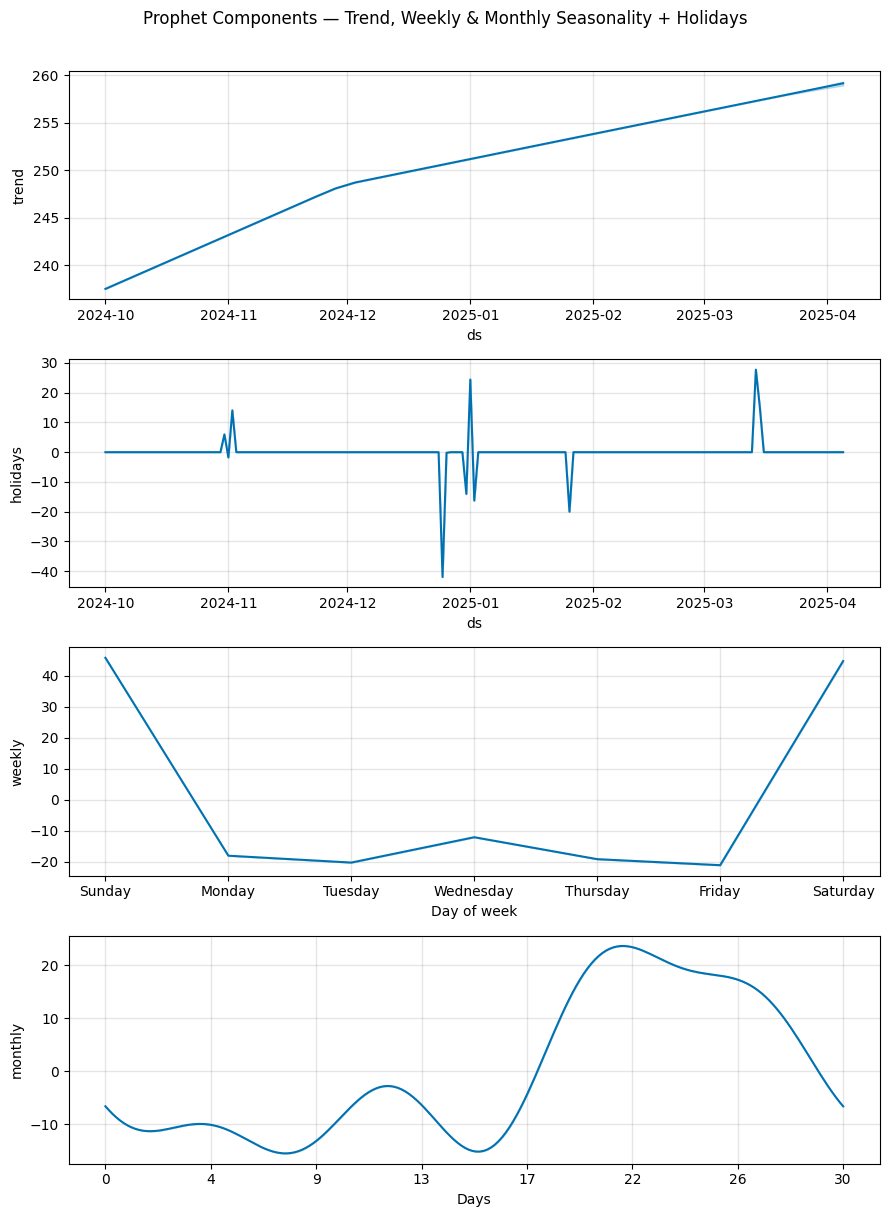

In [21]:
fig = m.plot_components(prophet_all)
plt.suptitle("Prophet Components — Trend, Weekly & Monthly Seasonality + Holidays",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
